In [ ]:
!pip install --quiet kaggle

In [ ]:
from google.colab import files
files.upload()   # choose kaggle.json

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"priyanshukakkad","key":"e83361d69f395563a2beca89d9c09b8d"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d priyanshukakkad/kcc-farmer-query-data-20212024 --unzip -p /content/kaggle_data
!ls -lah /content/kaggle_data

Dataset URL: https://www.kaggle.com/datasets/priyanshukakkad/kcc-farmer-query-data-20212024
License(s): unknown
 80% 73.0M/91.8M [00:00<00:00, 765MB/s]
100% 91.8M/91.8M [00:00<00:00, 723MB/s]
total 1.9G
drwxr-xr-x 2 root root 4.0K Nov  5 11:00 .
drwxr-xr-x 1 root root 4.0K Nov  5 11:00 ..
-rw-r--r-- 1 root root 206M Nov  5 11:00 KCC_2021.csv
-rw-r--r-- 1 root root  11M Nov  5 11:00 KCC_2022.csv
-rw-r--r-- 1 root root  37M Nov  5 11:00 KCC_2023.csv
-rw-r--r-- 1 root root 277M Nov  5 11:00 KCC_2024.csv
-rw-r--r-- 1 root root 290K Nov  5 09:20 kcc_logreg_baseline.pkl
-rw-r--r-- 1 root root 536M Nov  5 07:41 KCC_Merged_from_kaggle.csv
-rw-r--r-- 1 root root 539M Nov  5 10:58 KCC_Merged_from_kaggle_exactdedupe.csv
-rw-r--r-- 1 root root 143M Nov  5 10:58 KCC_Merged_from_kaggle_exactdedupe.parquet
-rw-r--r-- 1 root root 143M Nov  5 07:41 KCC_Merged_from_kaggle.parquet
-rw-r--r-- 1 root root 5.0M Nov  5 09:05 kcc_sample_for_modeling.parquet
-rw-r--r-- 1 root root  232 Nov  5 10:02 ml_baseline

In [ ]:
from pathlib import Path
import pandas as pd

data_dir = Path("/content/kaggle_data")
files = sorted(list(data_dir.glob("*.csv")))
print("Found files:", [f.name for f in files])

def preview_csv(path, n=3):
    for enc in ('utf-8','latin1'):
        try:
            df = pd.read_csv(path, encoding=enc, nrows=n)
            print(f"\nPreview {path.name} (encoding={enc}):")
            display(df.head(n))
            return
        except Exception as e:
            pass
    print(f"Could not preview {path.name} with utf-8/latin1 (will try full read later).")

for f in files:
    preview_csv(f)

Found files: ['KCC_2021.csv', 'KCC_2022.csv', 'KCC_2023.csv', 'KCC_2024.csv', 'KCC_Merged_from_kaggle.csv', 'KCC_Merged_from_kaggle_exactdedupe.csv', 'ml_baseline_classification_report.csv']

Preview KCC_2021.csv (encoding=utf-8):


,StateName,DistrictName,BlockName,Season,Sector,Category,Crop,QueryType,QueryText,KccAns,CreatedOn,year,month
0,MADHYA PRADESH,CHHATARPUR,BADA MALEHARA,NaN,AGRICULTURE,Others,Others,Weather,Farmer asked query on Weather,भारतीय मौसम विभाग से प्राप्त जानकारी के अनुसार...,2021-01-01T11:49:14.37,2021,1
1,MADHYA PRADESH,CHHATARPUR,NOWGONG,NaN,HORTICULTURE,Vegetables,Pea (Vegetable),Fertilizer Use and Availability,Farmer wants to know information about how to ...,मटर की फसल में दाने पर चमक लाने के लिए एवं ग्र...,2021-01-01T11:51:06.69,2021,1
2,MADHYA PRADESH,GUNA,RAGHOGARH,NaN,AGRICULTURE,Others,Others,Government Schemes,Farmer want to know information about prime mi...,आप आपके हल्का नम्बर पटवारी मोहदय से संपर्क क...,2021-01-01T11:59:21.697,2021,1



Preview KCC_2022.csv (encoding=utf-8):


,StateName,DistrictName,BlockName,Season,Sector,Category,Crop,QueryType,QueryText,KccAns,CreatedOn,year,month
0,MADHYA PRADESH,ASHOKNAGAR,ASHOKNAGAR,NaN,AGRICULTURE,Oilseeds,Soybean (bhat),Weather,Farmer asked query on Weather,प्रिय किसान भाई भारतीय मौसम विज्ञान विभाग से प...,2022-09-14T11:25:09.417,2022,9
1,MADHYA PRADESH,SAGAR,SAGAR,NaN,HORTICULTURE,Vegetables,Tomato,\tPlant Protection\t,Farmer wants to know how to control flower dro...,आप अपनी टमाटर फसल मैं फुल झड़न की रोकथाम के लिय...,2022-09-14T11:26:24.75,2022,9
2,MADHYA PRADESH,RAJGARH,NARSINGHGARH,NaN,AGRICULTURE,Others,Others,Weather,Farmer asked query on Weather,भारतीय मौसम विज्ञान के अनुसार आपके राजगढ़ जिले...,2022-09-14T11:26:30.193,2022,9



Preview KCC_2023.csv (encoding=utf-8):


...

,StateName,DistrictName,BlockName,Season,Sector,Category,Crop,QueryType,QueryText,KccAns,CreatedOn,year,month
0,MADHYA PRADESH,CHHATARPUR,BADA MALEHARA,NaN,AGRICULTURE,Others,Others,Weather,Farmer asked query on Weather,भारतीय मौसम विभाग से प्राप्त जानकारी के अनुसार...,2021-01-01T11:49:14.37,2021.0,1.0
1,MADHYA PRADESH,CHHATARPUR,NOWGONG,NaN,HORTICULTURE,Vegetables,Pea (Vegetable),Fertilizer Use and Availability,Farmer wants to know information about how to ...,मटर की फसल में दाने पर चमक लाने के लिए एवं ग्र...,2021-01-01T11:51:06.69,2021.0,1.0
2,MADHYA PRADESH,GUNA,RAGHOGARH,NaN,AGRICULTURE,Others,Others,Government Schemes,Farmer want to know information about prime mi...,आप आपके हल्का नम्बर पटवारी मोहदय से संपर्क क...,2021-01-01T11:59:21.697,2021.0,1.0



Preview KCC_Merged_from_kaggle_exactdedupe.csv (encoding=utf-8):


,StateName,DistrictName,BlockName,Season,Sector,Category,Crop,QueryType,QueryText,KccAns,CreatedOn,year,month,Unnamed: 0,precision,recall,f1-score,support
0,MADHYA PRADESH,CHHATARPUR,BADA MALEHARA,NaN,AGRICULTURE,Others,Others,Weather,Farmer asked query on Weather,भारतीय मौसम विभाग से प्राप्त जानकारी के अनुसार...,2021-01-01T11:49:14.37,2021.0,1.0,NaN,NaN,NaN,NaN,NaN
1,MADHYA PRADESH,CHHATARPUR,NOWGONG,NaN,HORTICULTURE,Vegetables,Pea (Vegetable),Fertilizer Use and Availability,Farmer wants to know information about how to ...,मटर की फसल में दाने पर चमक लाने के लिए एवं ग्र...,2021-01-01T11:51:06.69,2021.0,1.0,NaN,NaN,NaN,NaN,NaN
2,MADHYA PRADESH,GUNA,RAGHOGARH,NaN,AGRICULTURE,Others,Others,Government Schemes,Farmer want to know information about prime mi...,आप आपके हल्का नम्बर पटवारी मोहदय से संपर्क क...,2021-01-01T11:59:21.697,2021.0,1.0,NaN,NaN,NaN,NaN,NaN



Preview ml_baseline_classification_report.csv (encoding=utf-8):


,Unnamed: 0,precision,recall,f1-score,support
0,Kharif,0.651,0.737,0.691,1965.0
1,Rabi,0.677,0.502,0.577,1585.0
2,Zaid,0.407,0.478,0.439,850.0


In [ ]:
# Robust merge + remove exact duplicates (full-row) + save CSV & Parquet
import pandas as pd
from pathlib import Path

data_dir = Path("/content/kaggle_data")   # adjust if your download folder differs
csv_files = sorted(list(data_dir.glob("*.csv")))
print("Found CSVs:", [p.name for p in csv_files])
if not csv_files:
    raise SystemExit("No CSVs found in /content/kaggle_data - check path or unzip step.")

def read_csv_robust(path: Path):
    encs = ['utf-8','utf-8-sig','latin1','iso-8859-1','cp1252']
    for e in encs:
        try:
            df = pd.read_csv(path, encoding=e, low_memory=False)
            print(f"Loaded {path.name} with {e} -> {len(df):,} rows")
            return df
        except Exception:
            pass
    # chunk fallback (skip bad lines)
    print(f"Chunked fallback for {path.name} ... (this may take a while)")
    chunks = []
    for chunk in pd.read_csv(path, encoding='latin1', engine='python', chunksize=200_000, on_bad_lines='skip'):
        chunks.append(chunk)
    df = pd.concat(chunks, ignore_index=True)
    print(f"Chunked loaded {path.name} -> {len(df):,} rows")
    return df

# Read all files robustly
dfs = []
for p in csv_files:
    df = read_csv_robust(p)
    dfs.append(df)

# Concatenate
merged = pd.concat(dfs, ignore_index=True)
print("Rows after concat:", len(merged))

# Remove only exact (full-row) duplicates
before = len(merged)
merged = merged.drop_duplicates(keep='first')   # no subset => full-row dedupe
after = len(merged)
print(f"Removed exact full-row duplicates: {before - after:,} rows -> {after:,} remaining")

# Save merged outputs to disk
out_csv = data_dir / "KCC_Merged_from_kaggle_exactdedupe.csv"
out_parquet = data_dir / "KCC_Merged_from_kaggle_exactdedupe.parquet"
merged.to_csv(out_csv, index=False)
merged.to_parquet(out_parquet, index=False)
print("Saved merged CSV and Parquet to:", data_dir)

Found CSVs: ['KCC_2021.csv', 'KCC_2022.csv', 'KCC_2023.csv', 'KCC_2024.csv', 'KCC_Merged_from_kaggle.csv', 'KCC_Merged_from_kaggle_exactdedupe.csv', 'ml_baseline_classification_report.csv']
Loaded KCC_2021.csv with utf-8 -> 310,834 rows
Loaded KCC_2022.csv with latin1 -> 15,748 rows
Loaded KCC_2023.csv with utf-8 -> 50,684 rows
Loaded KCC_2024.csv with utf-8 -> 359,842 rows
Loaded KCC_Merged_from_kaggle.csv with utf-8 -> 733,343 rows
Loaded KCC_Merged_from_kaggle_exactdedupe.csv with utf-8 -> 733,349 rows
Loaded ml_baseline_classification_report.csv with utf-8 -> 6 rows
Rows after concat: 2203806
Removed exact full-row duplicates: 1,470,457 rows -> 733,349 remaining
Saved merged CSV and Parquet to: /content/kaggle_data


In [ ]:
import polars as pl
from pathlib import Path

p = Path("/content/kaggle_data/KCC_Merged_from_kaggle_exactdedupe.parquet")
df = pl.read_parquet(p)
print("Shape:", df.shape)
print("Columns:", df.columns)
display(df.head(5).to_pandas())

Shape: (733349, 18)
Columns: ['StateName', 'DistrictName', 'BlockName', 'Season', 'Sector', 'Category', 'Crop', 'QueryType', 'QueryText', 'KccAns', 'CreatedOn', 'year', 'month', 'Unnamed: 0', 'precision', 'recall', 'f1-score', 'support']


,StateName,DistrictName,BlockName,Season,Sector,Category,Crop,QueryType,QueryText,KccAns,CreatedOn,year,month,Unnamed: 0,precision,recall,f1-score,support
0,MADHYA PRADESH,CHHATARPUR,BADA MALEHARA,NaN,AGRICULTURE,Others,Others,Weather,Farmer asked query on Weather,भारतीय मौसम विभाग से प्राप्त जानकारी के अनुसार...,2021-01-01T11:49:14.37,2021.0,1.0,None,NaN,NaN,NaN,NaN
1,MADHYA PRADESH,CHHATARPUR,NOWGONG,NaN,HORTICULTURE,Vegetables,Pea (Vegetable),Fertilizer Use and Availability,Farmer wants to know information about how to ...,मटर की फसल में दाने पर चमक लाने के लिए एवं ग्र...,2021-01-01T11:51:06.69,2021.0,1.0,None,NaN,NaN,NaN,NaN
2,MADHYA PRADESH,GUNA,RAGHOGARH,NaN,AGRICULTURE,Others,Others,Government Schemes,Farmer want to know information about prime mi...,आप आपके हल्का नम्बर पटवारी मोहदय से संपर्क क...,2021-01-01T11:59:21.697,2021.0,1.0,None,NaN,NaN,NaN,NaN
3,MADHYA PRADESH,SEHORE,SEHORE,NaN,HORTICULTURE,Vegetables,Brinjal,Government Schemes,farmer want to know information about poly house?,किसान भाई आप पोली हाउस के बारे में जानकारी पता...,2021-01-05T09:33:14.857,2021.0,1.0,None,NaN,NaN,NaN,NaN
4,MADHYA PRADESH,SHAJAPUR,KALAPIPAL,NaN,AGRICULTURE,Pulses,Bengal Gram (Gram/Chick Pea/Kabuli/Chana),\tPlant Protection\t,Farmer needs information regarding caterpillar...,चने की फसल पे इल्लियों की समस्या के लिए स्प्रे...,2021-01-05T09:34:10.67,2021.0,1.0,None,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import numpy as np

# Load merged parquet
df = pd.read_parquet("/content/kaggle_data/KCC_Merged_from_kaggle_exactdedupe.parquet")

# ✅ Use actual column names
date_col = 'CreatedOn'
text_col = 'QueryText'

# Parse date column
df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=False)
df['year'] = df[date_col].dt.year
df['month'] = df[date_col].dt.month

# Map month → season
def month_to_season(m):
    if pd.isna(m): return None
    m = int(m)
    if m in [6,7,8,9,10]: return 'Kharif'
    if m in [11,12,1,2]: return 'Rabi'
    if m in [3,4,5]: return 'Zaid'
    return None

df['season'] = df['month'].apply(month_to_season)

print("✅ Added columns: year, month, season")
print(df['season'].value_counts(dropna=False))

✅ Added columns: year, month, season
season
Kharif    326078
Rabi      263203
Zaid      141049
None        3019
Name: count, dtype: int64


In [ ]:
import re

def clean_text(s):
    s = str(s).lower()
    s = re.sub(r'https?://\S+|www\.\S+', ' ', s)
    s = re.sub(r'[^a-z0-9\u0900-\u097F\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df['clean_text'] = df[text_col].astype(str).apply(clean_text)

print("✅ Cleaned text sample:")
print(df['clean_text'].head(5))

✅ Cleaned text sample:
0                        farmer asked query on weather
1    farmer wants to know information about how to ...
2    farmer want to know information about prime mi...
3     farmer want to know information about poly house
4    farmer needs information regarding caterpillar...
Name: clean_text, dtype: object


In [ ]:
#Baseline ML Model Start:
# Step 1: Load & Inspect (run this)
import polars as pl
from pathlib import Path

# ✅ Correct file path
p = Path("/content/kaggle_data/KCC_Merged_from_kaggle.parquet")

print("File exists:", p.exists())
df = pl.read_parquet(p)
print("Shape (rows, cols):", df.shape)
print("Columns:", df.columns)
display(df.head(5).to_pandas())

# Quick checks
print("\nSome value counts (season, sample):")
if 'season' in df.columns:
    print("season counts:\n", df['season'].value_counts().sort(by="counts").to_pandas())
else:
    print("No 'season' column found yet. We'll add it next.")

# Show sample of text column candidates
candidates = [c for c in df.columns if c.lower() in ['querytext','query_text','query','message','text','querytext']]
print("\nText-like columns found:", candidates)

File exists: True
Shape (rows, cols): (733343, 13)
Columns: ['StateName', 'DistrictName', 'BlockName', 'Season', 'Sector', 'Category', 'Crop', 'QueryType', 'QueryText', 'KccAns', 'CreatedOn', 'year', 'month']


,StateName,DistrictName,BlockName,Season,Sector,Category,Crop,QueryType,QueryText,KccAns,CreatedOn,year,month
0,MADHYA PRADESH,CHHATARPUR,BADA MALEHARA,NaN,AGRICULTURE,Others,Others,Weather,Farmer asked query on Weather,भारतीय मौसम विभाग से प्राप्त जानकारी के अनुसार...,2021-01-01T11:49:14.37,2021.0,1.0
1,MADHYA PRADESH,CHHATARPUR,NOWGONG,NaN,HORTICULTURE,Vegetables,Pea (Vegetable),Fertilizer Use and Availability,Farmer wants to know information about how to ...,मटर की फसल में दाने पर चमक लाने के लिए एवं ग्र...,2021-01-01T11:51:06.69,2021.0,1.0
2,MADHYA PRADESH,GUNA,RAGHOGARH,NaN,AGRICULTURE,Others,Others,Government Schemes,Farmer want to know information about prime mi...,आप आपके हल्का नम्बर पटवारी मोहदय से संपर्क क...,2021-01-01T11:59:21.697,2021.0,1.0
3,MADHYA PRADESH,SEHORE,SEHORE,NaN,HORTICULTURE,Vegetables,Brinjal,Government Schemes,farmer want to know information about poly house?,किसान भाई आप पोली हाउस के बारे में जानकारी पता...,2021-01-05T09:33:14.857,2021.0,1.0
4,MADHYA PRADESH,SHAJAPUR,KALAPIPAL,NaN,AGRICULTURE,Pulses,Bengal Gram (Gram/Chick Pea/Kabuli/Chana),\tPlant Protection\t,Farmer needs information regarding caterpillar...,चने की फसल पे इल्लियों की समस्या के लिए स्प्रे...,2021-01-05T09:34:10.67,2021.0,1.0



Some value counts (season, sample):
No 'season' column found yet. We'll add it next.

Text-like columns found: ['QueryText']


In [ ]:
# If you're fine using pandas from here on:
import polars as pl
import pandas as pd
import numpy as np

# If df is a Polars DataFrame, convert it (safe)
try:
    import polars as pl
    if isinstance(df, pl.DataFrame):
        df = df.to_pandas()
except Exception:
    pass

# Now the original mapping code will work
df["month"] = pd.to_numeric(df["month"], errors="coerce")
df["month"] = df["month"].fillna(0).astype(int)

def map_season(month):
    if month in [6,7,8,9,10]: return "Kharif"
    if month in [11,12,1,2]: return "Rabi"
    if month in [3,4,5]: return "Zaid"
    return np.nan

df["Season"] = df["month"].apply(map_season)
df = df.dropna(subset=["Season"])

print("✅ Added 'Season' column; counts:")
print(df["Season"].value_counts())


✅ Added 'Season' column; counts:
Season
Kharif    327434
Rabi      264282
Zaid      141625
Name: count, dtype: int64


In [ ]:
# Step 3 — Clean text data
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.lower()  # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)  # remove urls
    text = re.sub(r"[^a-zA-Z\u0900-\u097F\s]", " ", text)  # keep English + Hindi
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

df["CleanedText"] = df["QueryText"].apply(clean_text)

# Drop rows with empty cleaned text
df = df[df["CleanedText"].str.strip() != ""]

print("✅ Cleaned text column created successfully!")
print("Total rows after cleaning:", len(df))

# Quick preview
display(df[["QueryText", "CleanedText"]].head(10))

✅ Cleaned text column created successfully!
Total rows after cleaning: 733245


,QueryText,CleanedText
0,Farmer asked query on Weather,farmer asked query on weather
1,Farmer wants to know information about how to ...,farmer wants to know information about how to ...
2,Farmer want to know information about prime mi...,farmer want to know information about prime mi...
3,farmer want to know information about poly house?,farmer want to know information about poly house
4,Farmer needs information regarding caterpillar...,farmer needs information regarding caterpillar...
5,Farmer asked query on Weather,farmer asked query on weather
6,Farmer want to know information about how to ...,farmer want to know information about how to c...
7,farmer want to know information about govt. sc...,farmer want to know information about govt sch...
8,Farmer needs information regarding how to incr...,farmer needs information regarding how to incr...
9,Farmer needs information regarding how to incr...,farmer needs information regarding how to incr...


In [ ]:
# ensure df is a proper independent DataFrame (avoids SettingWithCopyWarning)
df = df.copy()

In [ ]:
# stratified sample by Season (3% or change)
sample_frac = 0.03
sample = df.groupby('Season', group_keys=False).apply(
    lambda x: x.sample(frac=min(sample_frac,1.0), random_state=42)
).reset_index(drop=True)

print("Sample shape:", sample.shape)
print(sample['Season'].value_counts())
# save sample for reuse
sample.to_parquet("/content/kaggle_data/kcc_sample_for_modeling.parquet", index=False)

/tmp/ipython-input-3633971107.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('Season', group_keys=False).apply(


Sample shape: (21997, 14)
Season
Kharif    9822
Rabi      7927
Zaid      4248
Name: count, dtype: int64


In [ ]:
!pip install -q nltk
import nltk
nltk.download('stopwords')

from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

stop_en = set(stopwords.words('english'))
hindi_stop = {"hai","ke","ki","ka","kya","ko","mein","se","aur","hai"}  # extend if needed

def tokenizer_simple(text):
    toks = text.split()
    return [t for t in toks if t not in stop_en and t not in hindi_stop and len(t)>1]

vectorizer = TfidfVectorizer(tokenizer=tokenizer_simple, ngram_range=(1,2), max_features=50000)
X = vectorizer.fit_transform(sample['CleanedText'].astype(str))
y = sample['Season'].astype(str)
print("TF-IDF matrix shape:", X.shape)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TF-IDF matrix shape: (21997, 12319)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_tr, X_te, y_tr, y_te = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
clf = LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga', n_jobs=-1)
clf.fit(X_tr, y_tr)
print("Model trained.")


Model trained.


              precision    recall  f1-score   support

      Kharif      0.651     0.737     0.691      1965
        Rabi      0.677     0.502     0.577      1585
        Zaid      0.407     0.478     0.439       850

    accuracy                          0.603      4400
   macro avg      0.578     0.572     0.569      4400
weighted avg      0.613     0.603     0.601      4400



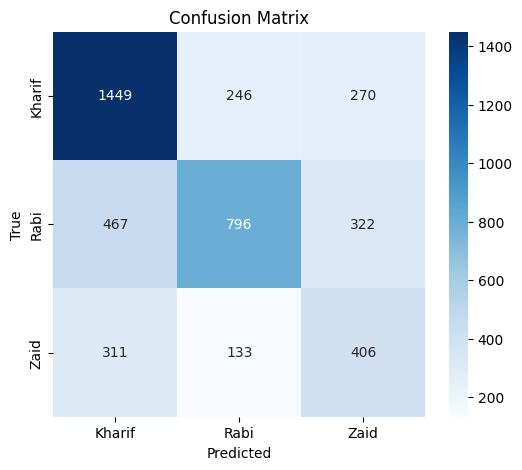

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = clf.predict(X_te)
print(classification_report(y_te, y_pred, digits=3))

labels = clf.classes_
cm = confusion_matrix(y_te, y_pred, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix'); plt.show()


In [ ]:
import pandas as pd
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df['Season'] = sample['Season'].values

topn = 15
for s in sorted(tfidf_df['Season'].unique()):
    means = tfidf_df[tfidf_df['Season']==s].drop(columns='Season').mean().sort_values(ascending=False)
    print(f"\nTop {topn} terms for {s}:")
    print(means.head(topn).index.tolist())



Top 15 terms for Kharif:
['query weather', 'asked query', 'query', 'weather', 'farmer asked', 'asked', 'farmer', 'information', 'know', 'crop', 'know information', 'wants', 'farmer wants', 'wants know', 'want']

Top 15 terms for Rabi:
['asked query', 'query weather', 'query', 'weather', 'farmer asked', 'asked', 'farmer', 'information', 'know', 'crop', 'know information', 'wants', 'farmer wants', 'wants know', 'wheat']

Top 15 terms for Zaid:
['asked query', 'query', 'query weather', 'weather', 'farmer asked', 'asked', 'farmer', 'information', 'know', 'know information', 'wants', 'farmer wants', 'crop', 'wants know', 'want']


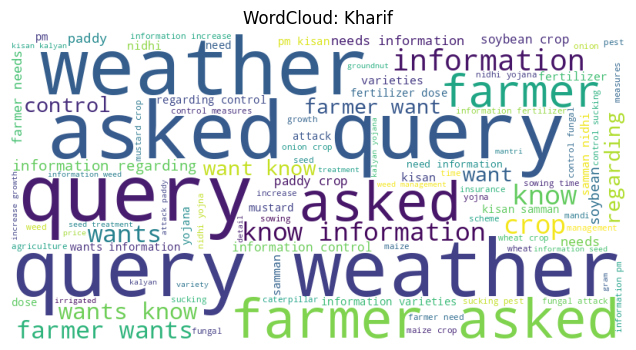

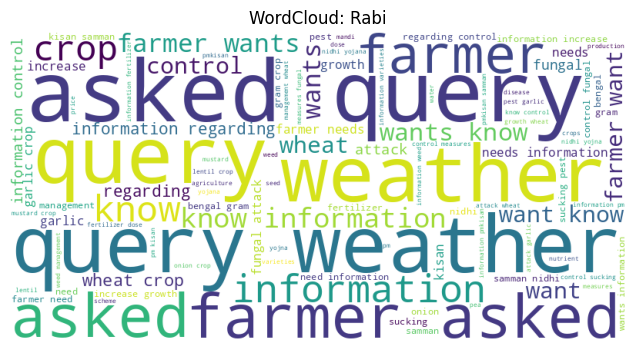

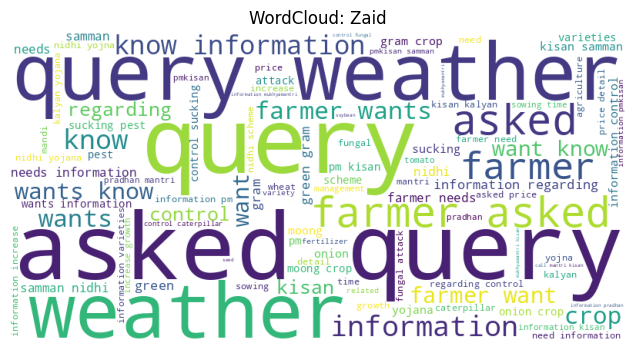

In [ ]:
!pip install -q wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for s in sorted(tfidf_df['Season'].unique()):
    means = tfidf_df[tfidf_df['Season']==s].drop(columns='Season').mean().sort_values(ascending=False).head(100)
    freqs = means.to_dict()
    wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freqs)
    plt.figure(figsize=(8,4)); plt.imshow(wc); plt.axis('off'); plt.title(f"WordCloud: {s}"); plt.show()


In [ ]:
import joblib
joblib.dump(clf, "/content/kaggle_data/kcc_logreg_baseline.pkl")
joblib.dump(vectorizer, "/content/kaggle_data/tfidf_vectorizer.pkl")
print("Saved model and vectorizer to /content/kaggle_data/")


Saved model and vectorizer to /content/kaggle_data/


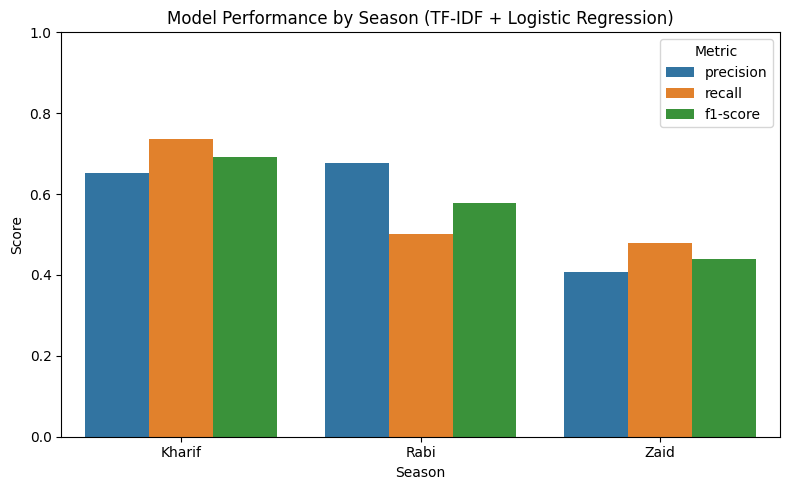

,precision,recall,f1-score,support
Kharif,0.651,0.737,0.691,1965.000
Rabi,0.677,0.502,0.577,1585.000
Zaid,0.407,0.478,0.439,850.000
accuracy,0.602,0.602,0.602,0.602
macro avg,0.578,0.572,0.569,4400.000
weighted avg,0.613,0.602,0.601,4400.000


Saved report CSV and performance plot to /content/kaggle_data/


<Figure size 640x480 with 0 Axes>

In [ ]:
# Corrected: build report_df, melt to long form, plot, and save assets
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# recreate classification report as DataFrame
report = classification_report(y_te, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)

# keep only the three season rows if present, else use available class rows
seasons = [s for s in ['Kharif','Rabi','Zaid'] if s in report_df.index]
perf_df = report_df.loc[seasons, ['precision','recall','f1-score']].reset_index().rename(columns={'index':'season'})

# melt to long form for seaborn
perf_long = perf_df.melt(id_vars='season', value_vars=['precision','recall','f1-score'],
                         var_name='metric', value_name='score')

# plot
plt.figure(figsize=(8,5))
sns.barplot(data=perf_long, x='season', y='score', hue='metric')
plt.ylim(0,1)
plt.title("Model Performance by Season (TF-IDF + Logistic Regression)")
plt.ylabel("Score")
plt.xlabel("Season")
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# show table and save
display(report_df)
report_df.to_csv("/content/kaggle_data/ml_baseline_classification_report.csv")
plt.savefig("/content/kaggle_data/ml_baseline_perf_plot.png", bbox_inches='tight')
print("Saved report CSV and performance plot to /content/kaggle_data/")


In [ ]:
# save everything for later reporting or comparison
import joblib

joblib.dump(report_df, "/content/kaggle_data/ml_baseline_metrics.pkl")
plt.savefig("/content/kaggle_data/ml_baseline_perf_plot.png")
print("📊 Report and visualization assets saved in /content/kaggle_data/")


📊 Report and visualization assets saved in /content/kaggle_data/


<Figure size 640x480 with 0 Axes>

In [ ]:
# DL Step 1: prepare environment + load a balanced subset (no training)
!pip install -q tensorflow sentencepiece


import os, random
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer

DATA_DIR = Path("/content/kaggle_data")
sample_path = DATA_DIR / "kcc_sample_for_modeling.parquet"
assert sample_path.exists(), f"Sample not found: {sample_path}"

# load sample (this is the stratified sample you created earlier)
sample = pd.read_parquet(sample_path)
sample = sample.sample(frac=1.0, random_state=42).reset_index(drop=True)

# map labels
labels = sorted(sample['Season'].unique().tolist())
label_map = {lab:i for i,lab in enumerate(labels)}
sample['label'] = sample['Season'].map(label_map)

# build balanced subset for DL (limit per class to n_per_class)
n_per_class = 8000   # change this value if you want smaller (e.g., 3000) or larger
parts = []
for s, g in sample.groupby('Season'):
    parts.append(g.sample(n=min(len(g), n_per_class), random_state=42))
sub = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)

# create tokenizer (we won't pad/seq yet)
MAX_VOCAB = 30000
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(sub['CleanedText'].astype(str).tolist())

print("Subset ready for DL:")
print(" - labels:", labels)
print(" - label_map:", label_map)
print(" - subset shape:", sub.shape)
print(" - per-label counts:\n", sub['label'].value_counts().to_dict())
print("\nTokenizer vocab size (fitted):", min(MAX_VOCAB, len(tokenizer.word_index)))


Subset ready for DL:
 - labels: ['Kharif', 'Rabi', 'Zaid']
 - label_map: {'Kharif': 0, 'Rabi': 1, 'Zaid': 2}
 - subset shape: (20175, 15)
 - per-label counts:
 {0: 8000, 1: 7927, 2: 4248}

Tokenizer vocab size (fitted): 2322


In [ ]:
# DL Step 2: create padded sequences and train/val split (no model)
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from sklearn.model_selection import train_test_split
import joblib

# Settings (you can adjust later)
MAX_VOCAB = 30000    # must match tokenizer used to fit
MAX_LEN   = 100      # sequence length (tokens). Increase for more context.
TEST_SIZE = 0.20
RANDOM_STATE = 42

# `sub` and `tokenizer` should exist from previous step.
# If not, load them (tokenizer from joblib if you saved it earlier):
# tokenizer = joblib.load("/content/kaggle_data/tokenizer.pkl")

texts = sub['CleanedText'].astype(str).tolist()
seqs = tokenizer.texts_to_sequences(texts)
X = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
y = np.array(sub['label'].values)

# train/val split (stratified)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=TEST_SIZE,
                                            stratify=y, random_state=RANDOM_STATE)

print("Tokenized & padded.")
print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("y_tr distribution:", np.bincount(y_tr))
print("y_val distribution:", np.bincount(y_val))

# Save arrays to disk (optional, speeds restart)
import numpy as _np
_np.save("/content/kaggle_data/X_tr.npy", X_tr)
_np.save("/content/kaggle_data/X_val.npy", X_val)
_np.save("/content/kaggle_data/y_tr.npy", y_tr)
_np.save("/content/kaggle_data/y_val.npy", y_val)
print("Saved X_tr/X_val/y_tr/y_val to /content/kaggle_data/ (npy)")


Tokenized & padded.
X_tr shape: (16140, 100)
X_val shape: (4035, 100)
y_tr distribution: [6400 6342 3398]
y_val distribution: [1600 1585  850]
Saved X_tr/X_val/y_tr/y_val to /content/kaggle_data/ (npy)


In [ ]:
# DL Step 3: Build & compile Bi-LSTM + Attention model (no training)
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# Hyperparameters — tweak if needed
MAX_VOCAB = 30000   # must match tokenizer num_words
MAX_LEN   = 100
EMB_DIM   = 128
LSTM_UNITS = 128
DROPOUT = 0.3
NUM_CLASSES = len(label_map)   # uses label_map from previous steps

# Attention layer that can return context vector (trained weights will be used at inference)
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        # weight vector for attention (features dim)
        self.W = self.add_weight(shape=(input_shape[-1],), initializer='glorot_uniform', trainable=True, name='att_w')
        super().build(input_shape)
    def call(self, inputs):
        # inputs: (batch, timesteps, features)
        score = tf.tensordot(inputs, self.W, axes=1)   # (batch, timesteps)
        weights = tf.nn.softmax(score, axis=1)         # (batch, timesteps)
        weights_exp = tf.expand_dims(weights, -1)      # (batch, timesteps, 1)
        context = tf.reduce_sum(inputs * weights_exp, axis=1)  # (batch, features)
        return context  # note: this returns context only; we'll modify for weights later if needed

# Build model
inp = Input(shape=(MAX_LEN,), dtype='int32', name='input_ids')
emb = layers.Embedding(input_dim=MAX_VOCAB, output_dim=EMB_DIM, mask_zero=True, name='embedding')(inp)
bilstm = layers.Bidirectional(layers.LSTM(LSTM_UNITS, return_sequences=True), name='bilstm')(emb)
att = AttentionLayer(name='attention')(bilstm)
drop = layers.Dropout(DROPOUT, name='dropout')(att)
out = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(drop)

model = Model(inputs=inp, outputs=out, name='BiLSTM_Attention')
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'attention' (of type AttentionLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 128)  │  3,840,000 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 100)       │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 100, 256)  │    263,168 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 256)       │        256 │ bilstm[0][0]      │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        771 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,104,195 (15.66 MB)

 Trainable params: 4,104,195 (15.66 MB)

 Non-trainable params: 0 (0.00 B)

Loaded shapes: (16140, 100) (4035, 100) (16140,) (4035,)
Epoch 1/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4879 - loss: 1.0441
Epoch 1: val_loss improved from inf to 0.90340, saving model to /content/kaggle_data/bilstm_attention_trained.h5


127/127 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.4882 - loss: 1.0436 - val_accuracy: 0.5745 - val_loss: 0.9034
Epoch 2/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 969ms/step - accuracy: 0.5994 - loss: 0.8797
Epoch 2: val_loss improved from 0.90340 to 0.87328, saving model to /content/kaggle_data/bilstm_attention_trained.h5


127/127 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.5994 - loss: 0.8796 - val_accuracy: 0.5844 - val_loss: 0.8733
Epoch 3/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/step - accuracy: 0.6218 - loss: 0.8289
Epoch 3: val_loss improved from 0.87328 to 0.87110, saving model to /content/kaggle_data/bilstm_attention_trained.h5


127/127 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.6218 - loss: 0.8289 - val_accuracy: 0.5958 - val_loss: 0.8711
Epoch 4/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 949ms/step - accuracy: 0.6259 - loss: 0.8070
Epoch 4: val_loss improved from 0.87110 to 0.85663, saving model to /content/kaggle_data/bilstm_attention_trained.h5


127/127 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.6258 - loss: 0.8070 - val_accuracy: 0.6050 - val_loss: 0.8566
Epoch 5/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 992ms/step - accuracy: 0.6456 - loss: 0.7790
Epoch 5: val_loss did not improve from 0.85663
127/127 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.6455 - loss: 0.7791 - val_accuracy: 0.5948 - val_loss: 0.8723
Restoring model weights from the end of the best epoch: 4.


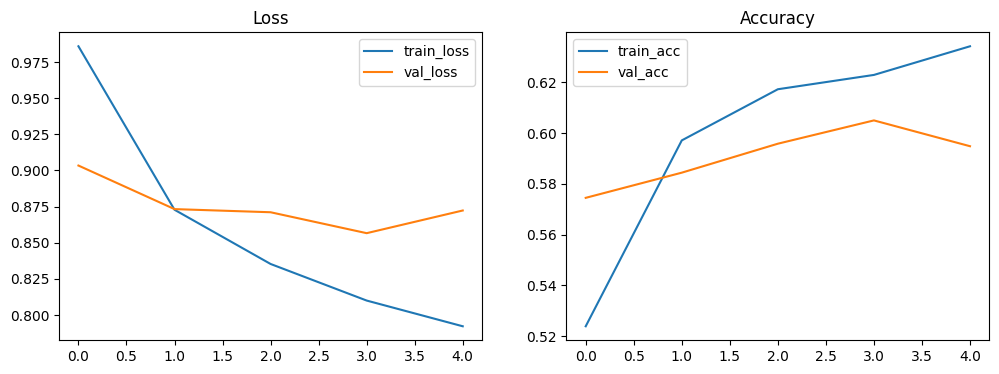

32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 256ms/step



Classification report (validation):
              precision    recall  f1-score   support

      Kharif      0.577     0.791     0.667      1600
        Rabi      0.661     0.581     0.619      1585
        Zaid      0.570     0.299     0.392       850

    accuracy                          0.605      4035
   macro avg      0.602     0.557     0.559      4035
weighted avg      0.608     0.605     0.590      4035

Saved tokenizer and model to /content/kaggle_data


In [ ]:
# DL Step 4: Train the compiled BiLSTM+Attention model, evaluate, and save
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

DATA_DIR = Path("/content/kaggle_data")

# load arrays (created in previous step)
X_tr = np.load(DATA_DIR / "X_tr.npy", mmap_mode=None)
X_val = np.load(DATA_DIR / "X_val.npy", mmap_mode=None)
y_tr = np.load(DATA_DIR / "y_tr.npy", mmap_mode=None)
y_val = np.load(DATA_DIR / "y_val.npy", mmap_mode=None)

print("Loaded shapes:", X_tr.shape, X_val.shape, y_tr.shape, y_val.shape)

# training hyperparameters
EPOCHS = 5       # change to 3 for a faster run
BATCH  = 128
MODEL_PATH = DATA_DIR / "bilstm_attention_trained.h5"

# callbacks
es = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1)
mc = ModelCheckpoint(MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=1)

# train
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=[es, mc],
    verbose=1
)

# plot training curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title("Accuracy")
plt.show()

# evaluate: preds and classification report
val_probs = model.predict(X_val, batch_size=BATCH)
val_preds = val_probs.argmax(axis=1)

# map numeric -> season label (uses label_map from earlier)
inv_label_map = {v:k for k,v in label_map.items()}
y_val_labels = [inv_label_map[int(i)] for i in y_val]
y_pred_labels = [inv_label_map[int(i)] for i in val_preds]

print("\nClassification report (validation):")
print(classification_report(y_val_labels, y_pred_labels, digits=3))

# save final model and tokenizer just in case (tokenizer exists from earlier)
import joblib
joblib.dump(tokenizer, DATA_DIR / "tokenizer_for_dl.pkl")
model.save(DATA_DIR / "bilstm_attention_final.h5")
print("Saved tokenizer and model to", DATA_DIR)
